# Librerias

In [42]:
import pandas as pd
import tensorflow as tf
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow_decision_forests as tfdf
import numpy as np
import keras
import seaborn as sns
from keras import layers
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, chi2 as chi2_dist
from sklearn.metrics import mean_absolute_error
#from ydata_profiling import ProfileReport


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  0
Built with CUDA: True


In [43]:
df = pd.read_csv('Datos/santiago_actualizado_final_REAL.csv')
#df = df.dropna()
df = df.drop(['id'], axis = 1)

In [44]:
columnas_criticas =['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']

for col in columnas_criticas:
    df[col] = np.log1p(df[col])

print("\n--- VALORES NUEVOS (Después del logaritmo) ---")
for col in columnas_criticas:
    print(f"{col.upper()}: Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}")


--- VALORES NUEVOS (Después del logaritmo) ---
PRICE: Skewness: 1.35, Kurtosis: 4.85
MINIMUM_NIGHTS: Skewness: 2.93, Kurtosis: 12.37
NUMBER_OF_REVIEWS: Skewness: 0.21, Kurtosis: -0.79
NUMBER_OF_REVIEWS_LTM: Skewness: 0.02, Kurtosis: -1.04


In [45]:
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,availability_365,number_of_reviews_ltm,archivo_fecha_origen,...,pax_nacional,pax_total,pax_total_var_pct,pax_total_ma3,alojamiento,comida_fuera,gas_licuado,mantencion_hogar,parafina,taxi
0,Santiago,-33.437666,-70.646033,Entire home/apt,10.596660,0.693147,1.098612,268,1.098612,2023-07-26,...,593935,1028696,0.2308,901873.0,50041.822511,2218.426105,13254.505298,21669.79822,755.767114,2995.853659
1,Santiago,-33.469590,-70.626490,Private room,9.606294,1.386294,1.945910,364,1.945910,2023-07-26,...,593935,1028696,0.2308,901873.0,50041.822511,2218.426105,13254.505298,21669.79822,755.767114,2995.853659
2,Santiago,-33.454630,-70.659130,Private room,10.182255,1.386294,0.693147,0,0.000000,2023-07-26,...,593935,1028696,0.2308,901873.0,50041.822511,2218.426105,13254.505298,21669.79822,755.767114,2995.853659
3,Santiago,-33.451410,-70.643540,Entire home/apt,9.998843,1.386294,4.382027,137,3.465736,2023-07-26,...,593935,1028696,0.2308,901873.0,50041.822511,2218.426105,13254.505298,21669.79822,755.767114,2995.853659
4,Las Condes,-33.395420,-70.548520,Entire home/apt,11.350418,2.079442,4.143135,147,2.079442,2023-07-26,...,593935,1028696,0.2308,901873.0,50041.822511,2218.426105,13254.505298,21669.79822,755.767114,2995.853659


# Analisis exploratorio de los datos

In [46]:
stats_df = df.describe(include='object').T
print("Estadísticas descriptivas:")
display(stats_df)

print("\nObservaciones duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:


,count,unique,top,freq
neighbourhood,189691,30,Santiago,67682
room_type,189691,4,Entire home/apt,147376
archivo_fecha_origen,189691,19,2025-08-29,13234
nombre_estacion,189691,121,Los Dominicos,16226
fecha_inauguracion_metro,184210,24,1980-08-31,37605



Observaciones duplicadas: 72
Valores nulos por columna:
neighbourhood                   0
latitude                        0
longitude                       0
room_type                       0
price                       10849
minimum_nights                  0
number_of_reviews               0
availability_365                0
number_of_reviews_ltm           0
archivo_fecha_origen            0
Dólar                           0
nombre_estacion                 0
fecha_inauguracion_metro     5481
antiguedad_metro_dias        5481
pax_internacional               0
pax_nacional                    0
pax_total                       0
pax_total_var_pct               0
pax_total_ma3                   0
alojamiento                     0
comida_fuera                    0
gas_licuado                     0
mantencion_hogar                0
parafina                        0
taxi                            0
dtype: int64


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189691 entries, 0 to 189690
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   neighbourhood             189691 non-null  object 
 1   latitude                  189691 non-null  float64
 2   longitude                 189691 non-null  float64
 3   room_type                 189691 non-null  object 
 4   price                     178842 non-null  float64
 5   minimum_nights            189691 non-null  float64
 6   number_of_reviews         189691 non-null  float64
 7   availability_365          189691 non-null  int64  
 8   number_of_reviews_ltm     189691 non-null  float64
 9   archivo_fecha_origen      189691 non-null  object 
 10  Dólar                     189691 non-null  int64  
 11  nombre_estacion           189691 non-null  object 
 12  fecha_inauguracion_metro  184210 non-null  object 
 13  antiguedad_metro_dias     184210 non-null  f

## Histogramas

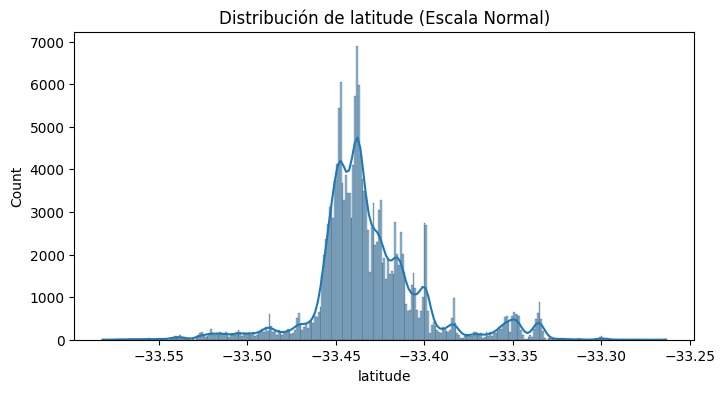

latitude - skewness> 0.55
latitude - Kurtosis> 2.72
------------------------------


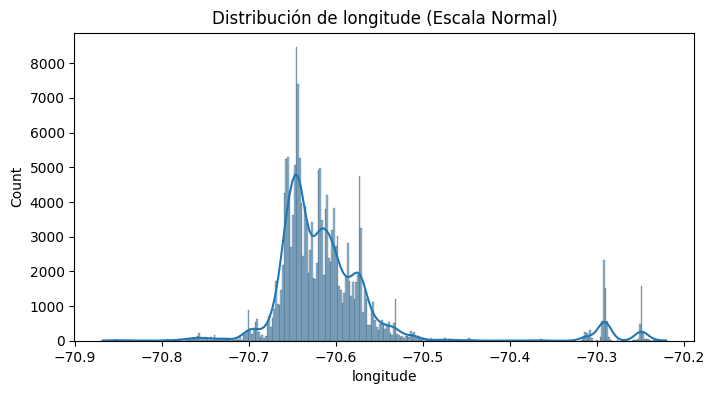

longitude - skewness> 2.75
longitude - Kurtosis> 8.75
------------------------------


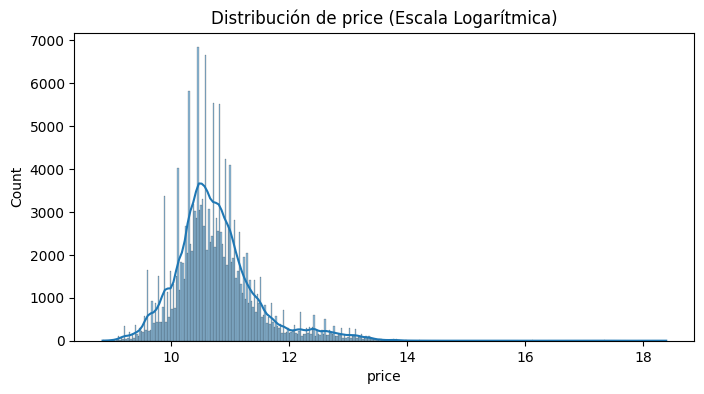

price - skewness> 1.35
price - Kurtosis> 4.85
------------------------------


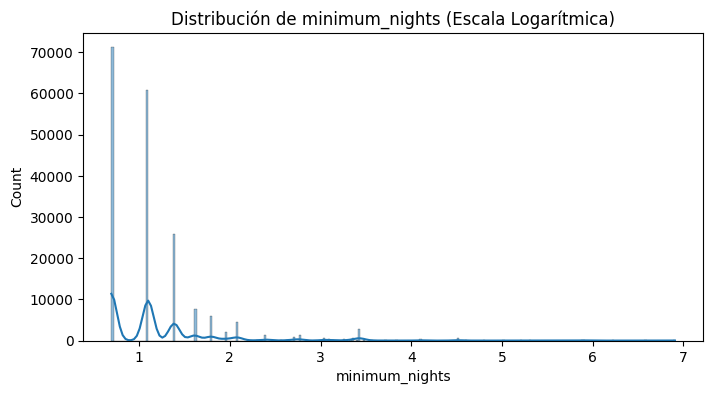

minimum_nights - skewness> 2.93
minimum_nights - Kurtosis> 12.37
------------------------------


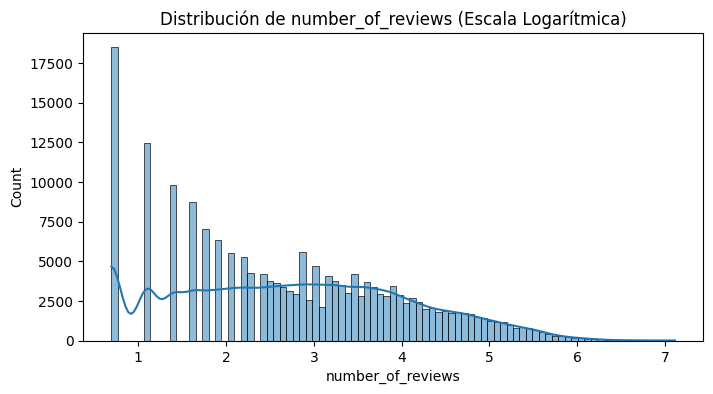

number_of_reviews - skewness> 0.21
number_of_reviews - Kurtosis> -0.79
------------------------------


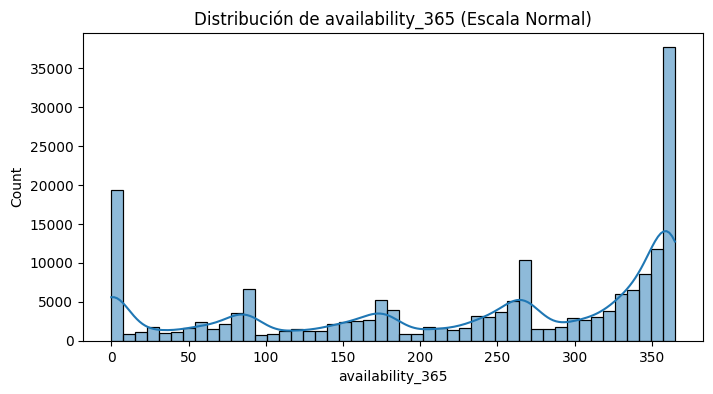

availability_365 - skewness> -0.59
availability_365 - Kurtosis> -1.08
------------------------------


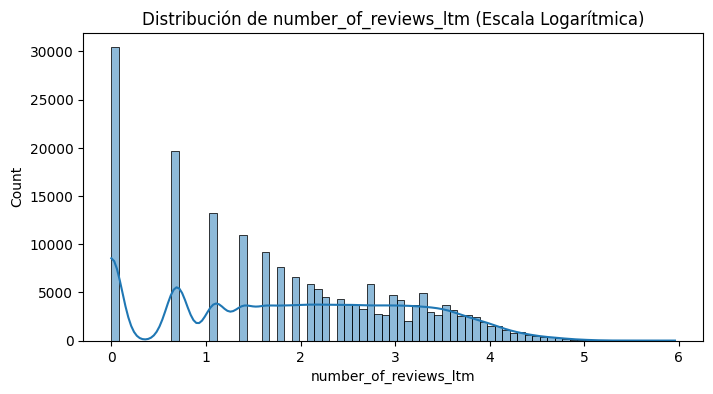

number_of_reviews_ltm - skewness> 0.02
number_of_reviews_ltm - Kurtosis> -1.04
------------------------------


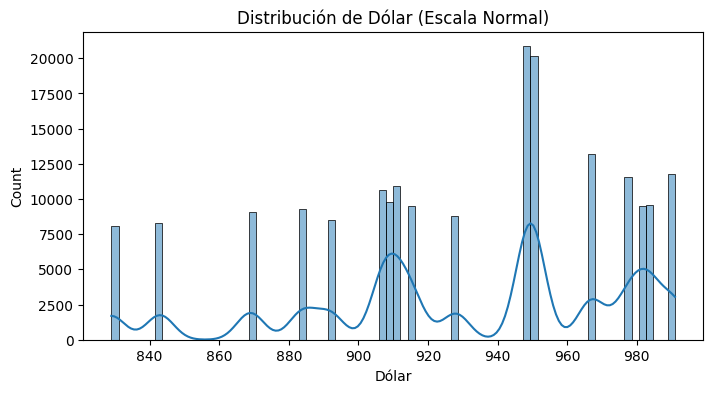

Dólar - skewness> -0.54
Dólar - Kurtosis> -0.56
------------------------------


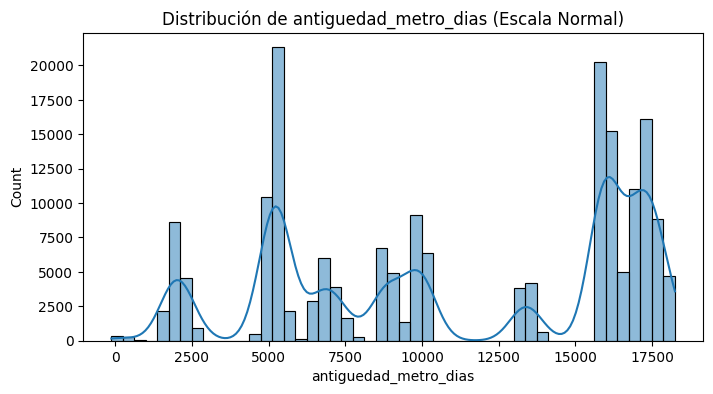

antiguedad_metro_dias - skewness> -0.23
antiguedad_metro_dias - Kurtosis> -1.49
------------------------------


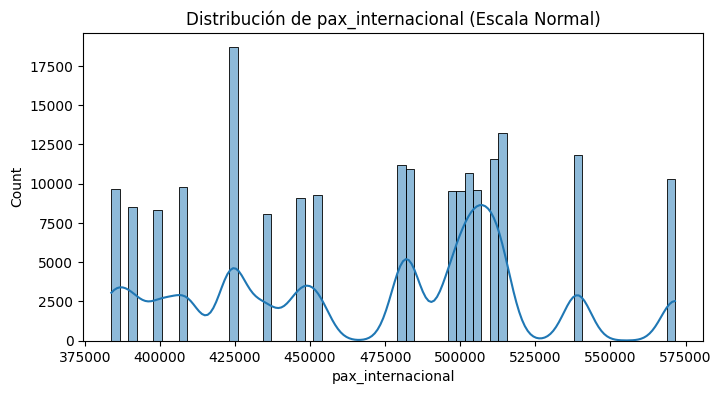

pax_internacional - skewness> -0.06
pax_internacional - Kurtosis> -0.96
------------------------------


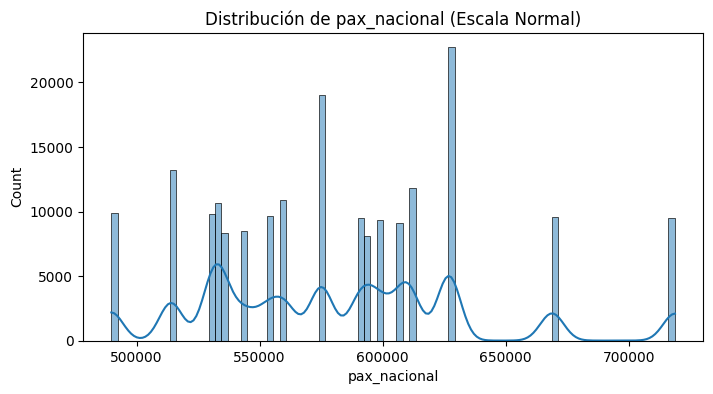

pax_nacional - skewness> 0.60
pax_nacional - Kurtosis> 0.17
------------------------------


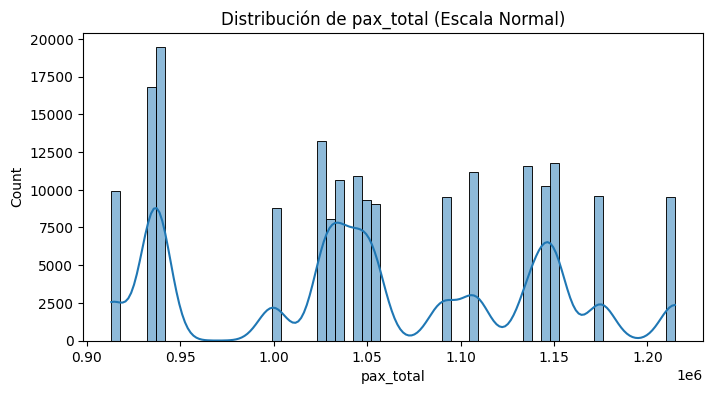

pax_total - skewness> 0.02
pax_total - Kurtosis> -1.04
------------------------------


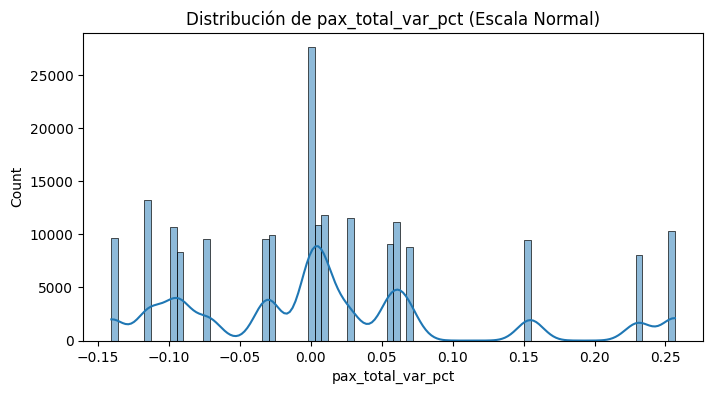

pax_total_var_pct - skewness> 0.83
pax_total_var_pct - Kurtosis> 0.27
------------------------------


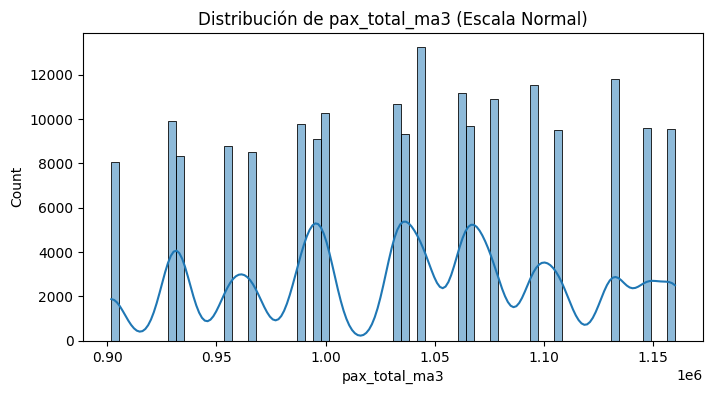

pax_total_ma3 - skewness> -0.10
pax_total_ma3 - Kurtosis> -0.94
------------------------------


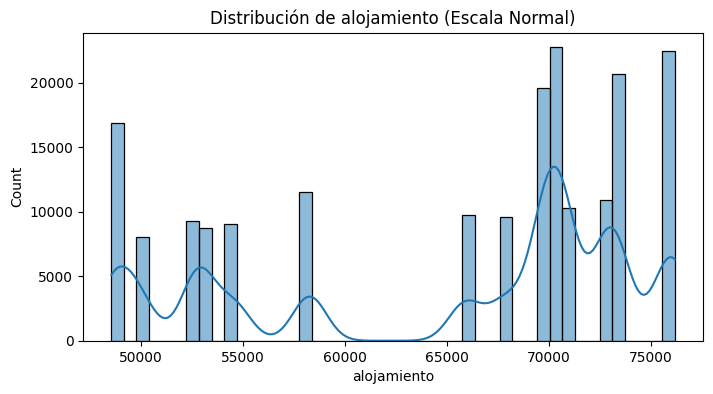

alojamiento - skewness> -0.62
alojamiento - Kurtosis> -1.20
------------------------------


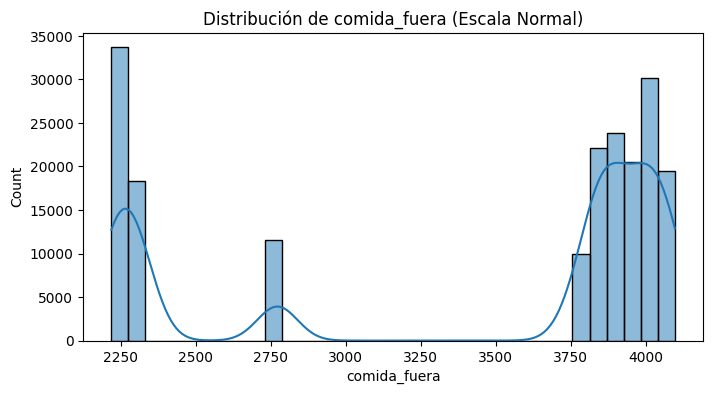

comida_fuera - skewness> -0.72
comida_fuera - Kurtosis> -1.36
------------------------------


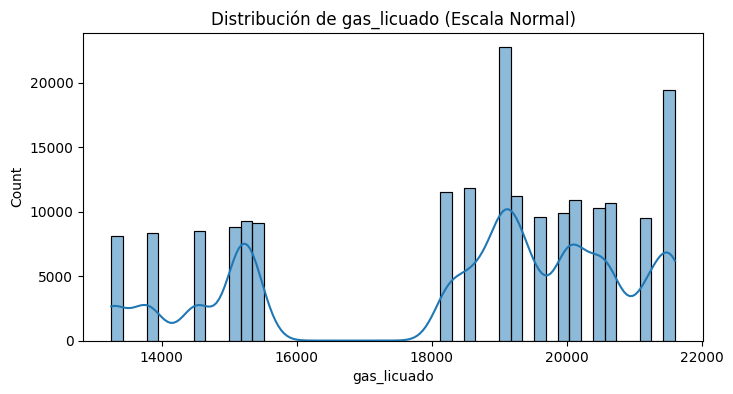

gas_licuado - skewness> -0.70
gas_licuado - Kurtosis> -0.86
------------------------------


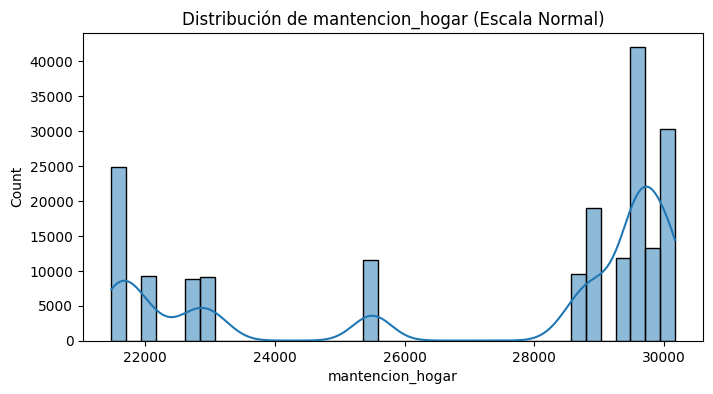

mantencion_hogar - skewness> -0.81
mantencion_hogar - Kurtosis> -1.16
------------------------------


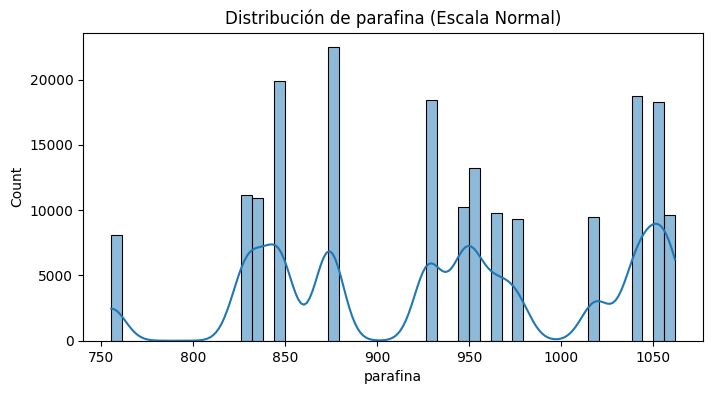

parafina - skewness> -0.12
parafina - Kurtosis> -1.08
------------------------------


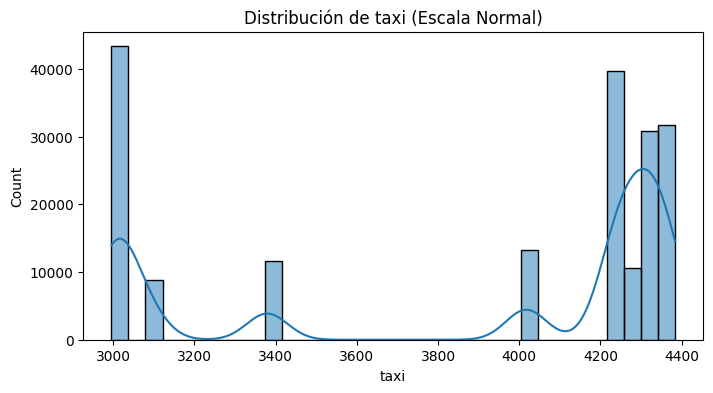

taxi - skewness> -0.70
taxi - Kurtosis> -1.39
------------------------------


In [48]:
variables_con_log = ['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']# Agrega aquí las que se vean mal

for columna in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))

    if columna in variables_con_log:
        sns.histplot(df[columna], kde=True)
        plt.title(f'Distribución de {columna} (Escala Logarítmica)')
    else:
        sns.histplot(df[columna], kde=True)
        plt.title(f'Distribución de {columna} (Escala Normal)')

    plt.show() 
    print(f'{columna} - skewness> {df[columna].skew():.2f}')
    print(f'{columna} - Kurtosis> {df[columna].kurt():.2f}')
    print('-'*30)


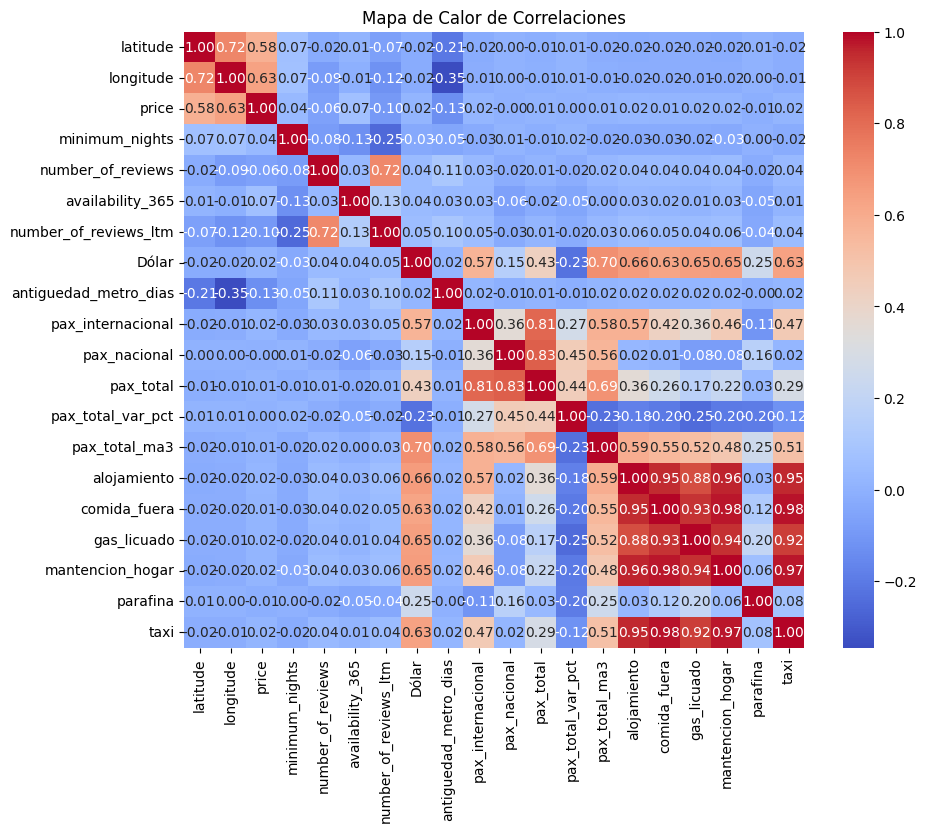

In [49]:
plt.figure(figsize=(10,8))
correlation_matrix = df.select_dtypes(include=(np.number)).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [50]:
categorical_columns = df.select_dtypes(include=['object']).columns
results = []
alpha = 0.5

for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
        chi2_crit = chi2_dist.ppf(1 - alpha, dof)
        results.append((col1, col2, chi2_stat, chi2_crit, p))
        
chi_results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Xi-cuadrado', 'Valor crítico', 'p-value']
)
print("Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):")
display(chi_results_df)

Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):


,Variable 1,Variable 2,Xi-cuadrado,Valor crítico,p-value
0,neighbourhood,room_type,1.203448e+04,86.334249,0.000000e+00
1,neighbourhood,archivo_fecha_origen,7.087052e+02,521.333485,8.703329e-08
2,neighbourhood,nombre_estacion,3.471625e+06,3479.333356,0.000000e+00
3,neighbourhood,fecha_inauguracion_metro,1.521567e+06,666.333452,0.000000e+00
4,room_type,archivo_fecha_origen,7.770967e+02,53.334816,1.012820e-128
5,room_type,nombre_estacion,2.703960e+04,359.333553,0.000000e+00
6,room_type,fecha_inauguracion_metro,1.008341e+04,68.334491,0.000000e+00
7,archivo_fecha_origen,nombre_estacion,2.085502e+03,2159.333370,8.721427e-01
8,archivo_fecha_origen,fecha_inauguracion_metro,6.618199e+02,413.333525,1.040675e-13
9,nombre_estacion,fecha_inauguracion_metro,4.236830e+06,2621.333363,0.000000e+00


# Modelos

In [ ]:
train_df = df.sample(frac=0.8, random_state=42) # se utiliza la funcion de pandas para retornar solo el 80% de los datos
test_df = df.drop(train_df.index) # Se elimina el 80% de los datos para retornar el 20%


train_df = tfdf.keras.pd_dataframe_to_tf_dataset( # Transforma el dataset en un diccionario de tensores para que el modelo lo pueda entender mejor
    train_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

test_df = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

train_df = train_df.prefetch(tf.data.AUTOTUNE)

## Gradient Boost 
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/GradientBoostedTreesModel

In [ ]:
model = tfdf.keras.GradientBoostedTreesModel(
    task = tfdf.keras.Task.REGRESSION, # Indica el objetivo del modelo
    num_trees = 3000,
    max_depth = 30,
    growing_strategy = "BEST_FIRST_GLOBAL", # Indica que pare cuando encuentre el primer mejor optimo global
    shrinkage = 0.1, # Tasa de aprendizaje
    l2_regularization = 0.1 # Penaliza al modelo cuando los valores en las hojas del modelo son muy extremos
)
model.fit(train_df)

In [ ]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (GBT)")
plt.grid(True)
plt.show()

In [ ]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())

real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

In [ ]:
inspector = model.make_inspector()

# Utiliza la funcion variable_importance para ver que tanto aporto cada variable.
# Se utiliza SUM_SCORE para ver el score de cada variable
importances = inspector.variable_importances()["SUM_SCORE"] # Retorna un diccionario

feature_names = [i[0].name for i in importances] # Convertir el diccionario en una lista
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values}) # Se transforma la lista en un Dataframe con columna variable y valor, las filas corresponderian a la importancia de las variables

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


# Crear el gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches: # patches es la barra de cada grafico
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Random Forest Regressor
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [ ]:
model_rf = tfdf.keras.RandomForestModel(
    task = tfdf.keras.Task.REGRESSION,
    num_trees = 500, 
    max_depth = 16, 
    growing_strategy = "BEST_FIRST_GLOBAL",
)
  
model_rf.fit(train_df) 

In [ ]:
logs = model_rf.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (GBT)")
plt.grid(True)
plt.show()

In [ ]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model_rf.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

# Graficar
plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

# Limitar los ejes si tienes esos outliers de 100 millones
plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Obtener el inspector del modelo
inspector = model_rf.make_inspector()

# 2. Extraer la importancia (usualmente usamos 'SUM_SCORE' o 'MEAN_DECREASE_IN_ACCURACY')
# SUM_SCORE indica cuánto contribuyó cada variable a reducir la varianza del precio
importances = inspector.variable_importances()["SUM_SCORE"]

# 3. Convertir a un DataFrame de Pandas para manejar porcentajes
feature_names = [i[0].name for i in importances]
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values})

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Crear el gráfico
ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Deep Neural Network

In [ ]:
columnas_categoricas = ['neighbourhood', 'room_type', 'nombre_estacion']

df_procesado = pd.get_dummies(df, columns=columnas_categoricas)

In [ ]:
df_procesado['archivo_fecha_origen'] = pd.to_datetime(df_procesado['archivo_fecha_origen'])
df_procesado['fecha_inauguracion_metro'] = pd.to_datetime(df_procesado['fecha_inauguracion_metro'])

# 2. Creamos nuevas columnas numéricas para el modelo
# Extraemos el año
df_procesado['archivo_fecha_origen_year'] = df_procesado['archivo_fecha_origen'].dt.year
df_procesado['fecha_inauguracion_metro_year'] = df_procesado['fecha_inauguracion_metro'].dt.year

# Extraemos el mes (muy útil para capturar temporadas altas en Airbnb)
df_procesado['archivo_fecha_origen_month'] = df_procesado['archivo_fecha_origen'].dt.month
df_procesado['fecha_inauguracion_metro_month'] = df_procesado['fecha_inauguracion_metro'].dt.month

# 3. Eliminamos las columnas originales de texto/fecha
# Ya no las necesitamos porque el modelo no las puede procesar
df_procesado = df_procesado.drop(['archivo_fecha_origen', 'fecha_inauguracion_metro'], axis=1)

print("Transformación de fechas completada.")
print(df_procesado)

In [ ]:
df_procesado = df_procesado.dropna()

In [ ]:
df_procesado.info()

In [ ]:
y = df_procesado['price']
x = df_procesado.drop(['price'], axis=1) # Se elimina la columna price y el resultado de eso se retorna a la variable x

# Separar los datos en train, validation, testing
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.01, random_state=42) #This return a data frame type
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.01, random_state=42)

scaler = StandardScaler()  # Se crea la variables StandardScaler para estandarizar las variables

x_train_scaled = scaler.fit_transform(x_train) # Se utiliza la variable fit_transform para normalizar los datos de x_train
x_val_scaled = scaler.transform(x_val)

print(x_train_scaled)
# Crear Dataset para optimizar TF
# Se utilizara la funcion from_tensor_slices la cual transformara los datos en objetos tf.data.Dataset
# A su vez crea un flujo para que los datos se vayan agregando a la tarjeta de video uno a la vez.
train_ds = tf.data.Dataset.from_tensor_slices((x_train_scaled, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_scaled, y_val.values))

# Optimizar Datasets
# Se utiliza shuffle para desordenar los datos en cada epoca
# batch agrupa los datos para que cada x cantidad de datos se cambien los pesos
# prefetch hace que mientras se estan entrenando datos, se este preparando el siguiente grupo
train_ds = train_ds.shuffle(buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
input_columns = x_train.shape[1]
model_mlp = keras.Sequential(
    [
        layers.Dense(256, activation="relu", input_shape=(input_columns,), name="layer1"),
        layers.BatchNormalization(), # Esto normaliza los datos para que haya una media cercana a 0 y una desviacion estandar cercana a 1
        layers.Dense(128, activation="relu", name="layer2"),
        layers.Dense(64, name="layer3"),
        layers.Dense(1)
    ]
)
model_mlp.summary()

In [ ]:
print(input_columns)

In [ ]:
model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='mean_squared_error',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()], # se utiliza mae para ver la diferencia real en precio a la que se esta
)

history = model_mlp.fit(
    train_ds,
    validation_data = val_ds,
    epochs=50,
    verbose = 1 # Para ver en terminal como va el entrenamiento
)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curva de Aprendizaje: Red Neuronal (MLP)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
x_test_scaled = scaler.transform(x_test)
test_ds = tf.data.Dataset.from_tensor_slices((x_test_scaled, y_test.values))
test_ds = test_ds.batch(32)

In [ ]:
all_labels = []
all_preds = []

for features, labels in test_ds:
    preds = model_mlp.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.4, color='orange', label='Predicciones MLP')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--', label='Ideal (45°)')
plt.title('Comparativa MLP: Precio Real vs. Predicho')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()
plt.xlim(0, 150000) # Ver solo hasta 300 mil pesos
plt.ylim(0, 150000)
plt.show()

In [ ]:
X_sample = x_test_scaled[:5000]
y_sample = y_test.values[:5000]

baseline_preds = model_mlp.predict(X_sample, verbose=0)
baseline_mae = mean_absolute_error(y_sample, baseline_preds)

importances = []
feature_names = x_test.columns 

for i in range(X_sample.shape[1]):
    # Guardamos la columna original
    save_col = X_sample[:, i].copy()
    
    # Desordenamos la columna i
    np.random.shuffle(X_sample[:, i])
    
    # Medimos el nuevo error
    shuffled_preds = model_mlp.predict(X_sample, verbose=0)
    shuffled_mae = mean_absolute_error(y_sample, shuffled_preds)
    
    # La importancia es cuánto aumentó el error (en pesos o log-puntos)
    importances.append(shuffled_mae - baseline_mae)
    
    # Restauramos la columna original para la siguiente iteración
    X_sample[:, i] = save_col

# 2. Crear tabla y graficar
df_todas = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})

# 2. Definimos la función de mapeo para agrupar las 179 columnas
def mapear_categoria(nombre):
    if 'nombre_estacion_' in nombre:
        return 'Sistema Metro (Conectividad)'
    elif 'neighbourhood_' in nombre:
        return 'Ubicación por Comuna'
    elif 'room_type_' in nombre:
        return 'Tipo de Propiedad'
    elif 'archivo_fecha_origen_' in nombre:
        return 'Temporalidad (Año/Mes)'
    elif 'fecha_inauguracion_metro_' in nombre:
        return 'Antigüedad del Sector (Metro)'
    elif nombre in ['latitude', 'longitude']:
        return 'Coordenadas Geográficas (GPS)'
    elif nombre in ['pax_internacional', 'pax_nacional', 'pax_total']:
        return 'Flujo de Pasajeros (Aeropuerto)'
    elif nombre in ['alojamiento', 'comida_fuera', 'gas_licuado', 'parafina']:
        return 'Variables Económicas (IPC/Costo Vida)'
    else:
        # Para variables únicas como 'minimum_nights', 'Dólar', 'availability_365', etc.
        return nombre 

# 3. Aplicamos el agrupamiento a las 179 filas
df_todas['Categoria_Consolidada'] = df_todas['Variable'].apply(mapear_categoria)

# 4. Sumamos las importancias de cada grupo
# Esto es vital: suma el impacto de las 100+ estaciones en una sola métrica
df_final = df_todas.groupby('Categoria_Consolidada')['Importancia'].sum().reset_index()

# 5. Ordenamos de mayor a menor para que el gráfico sea legible
df_final = df_final.sort_values(by='Importancia', ascending=False)

# 6. Graficamos el 100% de tus datos agrupados
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Categoria_Consolidada', data=df_final, palette='viridis')

# Añadimos los valores exactos al final de cada barra para mayor precisión técnica
for i, val in enumerate(df_final['Importancia']):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.title('Importancia Global de Variables Consolidadas - MLP', fontsize=14)
plt.xlabel('Impacto Acumulado en el Error (MAE)', fontsize=12)
plt.ylabel('Categoría de Datos', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()